---
## Dataset Collection

We use two CSV files from the IPL Complete Dataset on Kaggle:
- `matches.csv` — one row per match, contains match-level metadata
- `deliveries.csv` — one row per ball bowled, contains ball-by-ball data

In [26]:
import os

DATA_DIR = "data"
matches_path    = os.path.join(DATA_DIR, "matches.csv")
deliveries_path = os.path.join(DATA_DIR, "deliveries.csv")

# Check files exist
for path in [matches_path, deliveries_path]:
    status = "Found" if os.path.exists(path) else "NOT FOUND — please download from Kaggle"
    print(f"{path}: {status}")


data\matches.csv: Found
data\deliveries.csv: Found


In [27]:
import warnings
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
os.makedirs("output", exist_ok=True)

print("All libraries loaded successfully")


All libraries loaded successfully


---
## Data Loading

Load both CSV files and inspect their shape and columns.

In [28]:
matches    = pd.read_csv(matches_path)
deliveries = pd.read_csv(deliveries_path)

print(f"matches.csv    : {matches.shape[0]:,} rows × {matches.shape[1]} columns")
print(f"deliveries.csv : {deliveries.shape[0]:,} rows × {deliveries.shape[1]} columns")


matches.csv    : 1,095 rows × 20 columns
deliveries.csv : 260,920 rows × 17 columns


In [29]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [30]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [31]:
print("matches.csv columns:\n",    list(matches.columns))
print("\ndeliveries.csv columns:\n", list(deliveries.columns))


matches.csv columns:
 ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

deliveries.csv columns:
 ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [32]:
print("Missing values in deliveries.csv:")
print(deliveries.isnull().sum()[deliveries.isnull().sum() > 0])


Missing values in deliveries.csv:
extras_type         246795
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


---
## Data Cleaning

We:
- Keep only **first innings** rows
- Remove Duckworth-Lewis affected matches
- Filter to **recognised IPL franchises** only
- Drop rows with missing team names

In [33]:

df = deliveries[deliveries["inning"] == 1].copy()

df.dropna(subset=["batting_team", "bowling_team"], inplace=True)

if "dl_applied" in matches.columns:
    valid_ids = matches[matches["dl_applied"] == 0]["id"]
    df = df[df["match_id"].isin(valid_ids)]


valid_teams = [
    "Mumbai Indians", "Chennai Super Kings", "Royal Challengers Bangalore",
    "Kolkata Knight Riders", "Delhi Capitals", "Sunrisers Hyderabad",
    "Punjab Kings", "Rajasthan Royals", "Deccan Chargers",
    "Kochi Tuskers Kerala", "Pune Warriors", "Delhi Daredevils",
    "Kings XI Punjab", "Rising Pune Supergiants", "Gujarat Lions",
    "Lucknow Super Giants", "Gujarat Titans",
]
df = df[df["batting_team"].isin(valid_teams) & df["bowling_team"].isin(valid_teams)]

print(f"Rows after cleaning: {len(df):,}")
df.head()


Rows after cleaning: 131,166


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


---
## Feature Engineering

For each match, we compute cumulative statistics **over-by-over** and calculate:

| Feature | Formula |
|---|---|
| `cumulative_runs` | Runs scored so far |
| `cumulative_wickets` | Wickets fallen so far |
| `balls_left` | 120 − balls bowled |
| `wickets_left` | 10 − wickets fallen |
| `crr` | Runs ÷ overs done (current run rate) |

We also compute the **final score** per match as our target label `y`.

In [34]:

df["cumulative_runs"]    = df.groupby("match_id")["total_runs"].cumsum()
df["cumulative_wickets"] = df.groupby("match_id")["player_dismissed"].transform(
    lambda x: x.notna().cumsum()
)
df["ball_number"] = df.groupby("match_id").cumcount() + 1
df["overs_done"]  = (df["ball_number"] - 1) // 6 + 1


final_scores = (
    df.groupby("match_id")["total_runs"].sum().reset_index(name="final_score")
)
df = df.merge(final_scores, on="match_id")


df_over = (
    df.sort_values(["match_id", "ball_number"])
    .groupby(["match_id", "overs_done"])
    .last()
    .reset_index()
)


df_over["balls_left"]   = 120 - df_over["ball_number"]
df_over["wickets_left"] = 10  - df_over["cumulative_wickets"]
df_over["crr"]          = df_over["cumulative_runs"] / df_over["overs_done"]


df_over = df_over[df_over["overs_done"] >= 6].copy()

print(f"Feature matrix shape: {df_over.shape}")
df_over[["batting_team", "bowling_team", "overs_done",
         "cumulative_runs", "wickets_left", "balls_left",
         "crr", "final_score"]].head()


Feature matrix shape: (17005, 25)


,batting_team,bowling_team,overs_done,cumulative_runs,wickets_left,balls_left,crr,final_score
5,Kolkata Knight Riders,Royal Challengers Bangalore,6,61,9,84,10.166667,222
6,Kolkata Knight Riders,Royal Challengers Bangalore,7,66,9,78,9.428571,222
7,Kolkata Knight Riders,Royal Challengers Bangalore,8,71,9,72,8.875000,222
8,Kolkata Knight Riders,Royal Challengers Bangalore,9,74,9,66,8.222222,222
9,Kolkata Knight Riders,Royal Challengers Bangalore,10,80,9,60,8.000000,222


---
## Encoding


Convert categorical team names into numerical form using **One-Hot Encoding** (`pd.get_dummies`).  
This creates a binary column for each team (e.g. `bat_Mumbai Indians`, `bowl_Chennai Super Kings`).

In [35]:

team_dummies = pd.get_dummies(
    df_over[["batting_team", "bowling_team"]],
    prefix=["bat", "bowl"]
)

NUMERIC_FEATURES = ["cumulative_runs", "wickets_left", "balls_left", "crr", "overs_done"]

X = pd.concat(
    [df_over[NUMERIC_FEATURES].reset_index(drop=True),
     team_dummies.reset_index(drop=True)],
    axis=1
)
y = df_over["final_score"].reset_index(drop=True)

FEATURE_COLUMNS = list(X.columns)

print(f"Total features : {X.shape[1]}")
print(f"  Numeric      : {len(NUMERIC_FEATURES)}")
print(f"  Team dummies : {len(team_dummies.columns)}")
print(f"Target samples : {len(y):,}")
X.head()


Total features : 39
  Numeric      : 5
  Team dummies : 34
Target samples : 17,005


,cumulative_runs,wickets_left,balls_left,crr,overs_done,bat_Chennai Super Kings,bat_Deccan Chargers,bat_Delhi Capitals,bat_Delhi Daredevils,bat_Gujarat Lions,...,bowl_Kochi Tuskers Kerala,bowl_Kolkata Knight Riders,bowl_Lucknow Super Giants,bowl_Mumbai Indians,bowl_Pune Warriors,bowl_Punjab Kings,bowl_Rajasthan Royals,bowl_Rising Pune Supergiants,bowl_Royal Challengers Bangalore,bowl_Sunrisers Hyderabad
0,61,9,84,10.166667,6,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,66,9,78,9.428571,7,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,71,9,72,8.875000,8,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,74,9,66,8.222222,9,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,80,9,60,8.000000,10,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


---
## Train-Test Split

Split the dataset: **80% training**, **20% testing** using `train_test_split`.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train):,}")
print(f"Testing  samples : {len(X_test):,}")


Training samples : 13,604
Testing  samples : 3,401


---
## Model Training

Train a **Linear Regression** model on the training set using scikit-learn's `.fit()` method.

In [37]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Intercept : {model.intercept_:.2f}")


Model trained successfully!
Intercept : 114.46


---
## Prediction

Generate predictions on the test set and compare against actual scores.

In [38]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Score"   : y_test.values[:15],
    "Predicted Score": np.round(y_pred[:15]).astype(int),
    "Error"          : np.round(y_test.values[:15] - y_pred[:15]).astype(int)
})
comparison


,Actual Score,Predicted Score,Error
0,153,168,-15
1,155,161,-6
2,120,147,-27
3,163,152,11
4,205,198,7
5,161,169,-8
6,223,221,2
7,113,118,-5
8,178,157,21
9,172,167,5


---
## Model Evaluation

Evaluate using **Mean Absolute Error (MAE)** and **R² Score**.

In [39]:
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE) : {mae:.2f} runs")
print(f"R² Score                  : {r2:.4f}")
print()
print(f"📌 The model is off by ~{mae:.1f} runs on average.")
print(f"📌 R² of {r2:.2f} → model explains {r2*100:.1f}% of score variance.")


Mean Absolute Error (MAE) : 13.00 runs
R² Score                  : 0.6841

📌 The model is off by ~13.0 runs on average.
📌 R² of 0.68 → model explains 68.4% of score variance.


---
## Visualization

Plot four diagnostic charts:
1. Actual vs Predicted scores
2. Residual plot
3. Distribution of prediction errors
4. Top feature coefficients

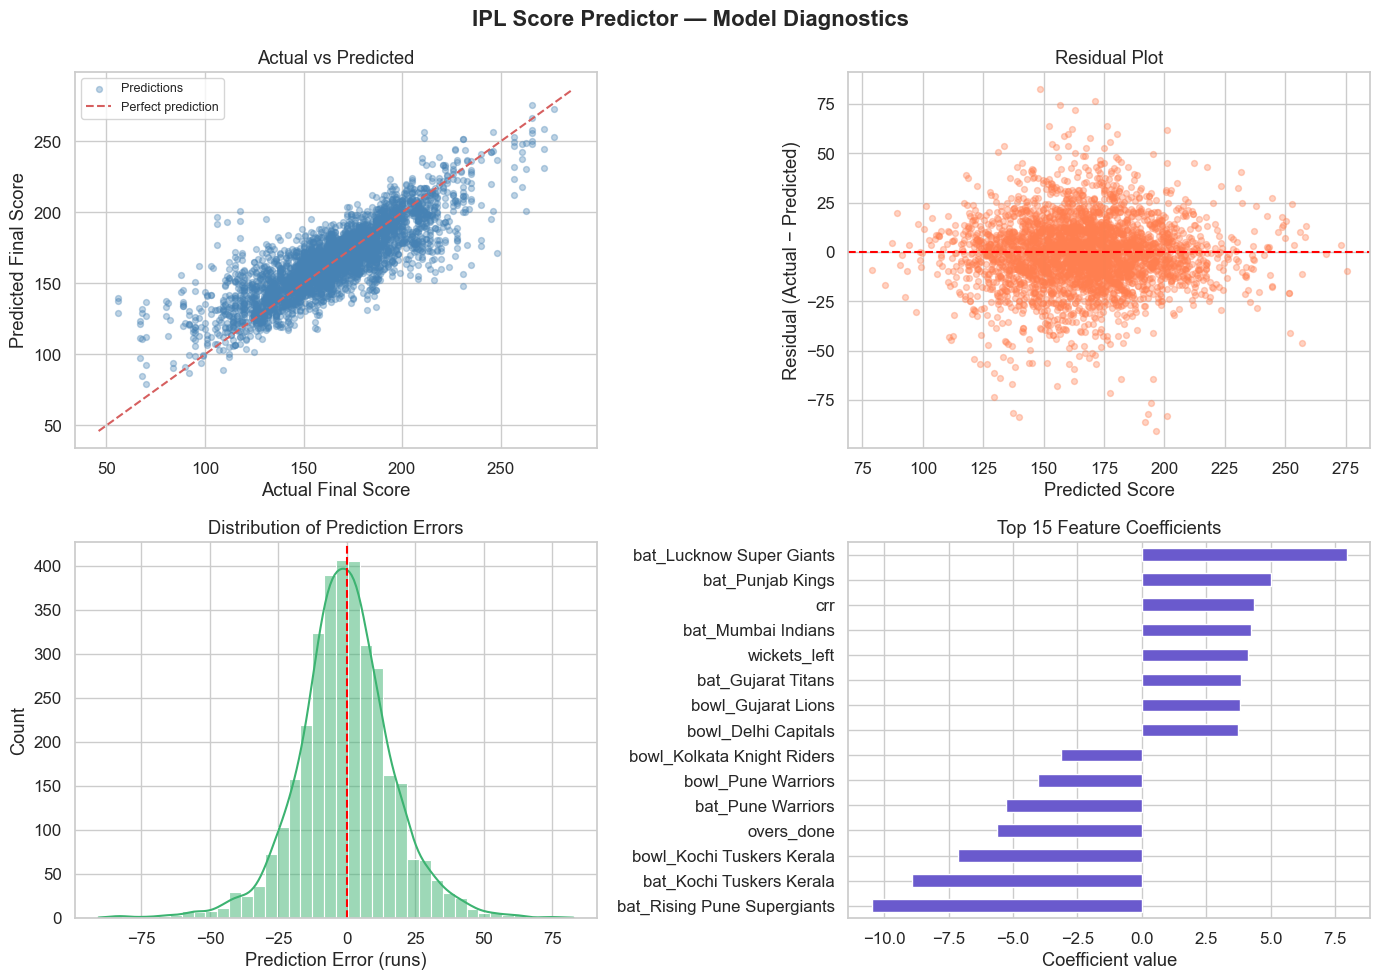

Saved 


In [40]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("IPL Score Predictor — Model Diagnostics", fontsize=16, fontweight="bold")

ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred, alpha=0.35, s=18, color="steelblue", label="Predictions")
lims = [min(y_test.min(), y_pred.min()) - 10, max(y_test.max(), y_pred.max()) + 10]
ax1.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax1.set_xlabel("Actual Final Score")
ax1.set_ylabel("Predicted Final Score")
ax1.set_title("Actual vs Predicted")
ax1.legend(fontsize=9)


residuals = y_test.values - y_pred
ax2 = axes[0, 1]
ax2.scatter(y_pred, residuals, alpha=0.35, s=18, color="coral")
ax2.axhline(0, color="red", linewidth=1.5, linestyle="--")
ax2.set_xlabel("Predicted Score")
ax2.set_ylabel("Residual (Actual − Predicted)")
ax2.set_title("Residual Plot")

ax3 = axes[1, 0]
sns.histplot(residuals, bins=40, kde=True, ax=ax3, color="mediumseagreen")
ax3.axvline(0, color="red", linestyle="--")
ax3.set_xlabel("Prediction Error (runs)")
ax3.set_title("Distribution of Prediction Errors")


ax4 = axes[1, 1]
coef_series = pd.Series(model.coef_, index=FEATURE_COLUMNS)
top15 = coef_series.abs().nlargest(15).index
coef_series[top15].sort_values().plot(kind="barh", ax=ax4, color="slateblue")
ax4.set_xlabel("Coefficient value")
ax4.set_title("Top 15 Feature Coefficients")

plt.tight_layout()
plt.savefig("output/model_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ")


---
## Phase 13 — Model Saving

Save the trained model and feature column list using `pickle` so we can reload them later without retraining.

In [41]:
with open("output/ipl_score_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("output/feature_columns.pkl", "wb") as f:
    pickle.dump(FEATURE_COLUMNS, f)

print("Model saved")
print("Features saved")


Model saved
Features saved


---
## Manual Prediction

Use the trained model to predict a score for any match scenario.

In [42]:
def predict_score(batting_team, bowling_team, current_score,
                  wickets_fallen, overs_done):
    """
    Predict final first-innings IPL score.

    Parameters
    ----------
    batting_team   : str  — e.g. 'Mumbai Indians'
    bowling_team   : str  — e.g. 'Chennai Super Kings'
    current_score  : int  — runs scored so far
    wickets_fallen : int  — wickets lost (0–9)
    overs_done     : float — overs completed, e.g. 12.4

    Returns
    -------
    int : predicted final score
    """
    balls_done   = int(overs_done) * 6 + round((overs_done % 1) * 10)
    balls_left   = max(120 - balls_done, 0)
    wickets_left = 10 - wickets_fallen
    crr          = current_score / max(overs_done, 0.1)

    row = {col: 0 for col in FEATURE_COLUMNS}
    row.update({
        "cumulative_runs": current_score,
        "wickets_left":    wickets_left,
        "balls_left":      balls_left,
        "crr":             crr,
        "overs_done":      overs_done,
    })
    if f"bat_{batting_team}"  in row: row[f"bat_{batting_team}"]  = 1
    if f"bowl_{bowling_team}" in row: row[f"bowl_{bowling_team}"] = 1

    pred = model.predict(pd.DataFrame([row]))[0]
    return max(int(round(pred)), current_score)


batting_team   = "Mumbai Indians"
bowling_team   = "Chennai Super Kings"
current_score  = 87
wickets_fallen = 3
overs_done     = 12.0

result = predict_score(batting_team, bowling_team,
                       current_score, wickets_fallen, overs_done)

print(f"Match    : {batting_team} vs {bowling_team}")
print(f"State    : {current_score}/{wickets_fallen} after {overs_done} overs")
print(f"\n Predicted Final Score: {result}")


Match    : Mumbai Indians vs Chennai Super Kings
State    : 87/3 after 12.0 overs

 Predicted Final Score: 164
